In [79]:
import numpy as np
import matplotlib.pyplot as plt

In [80]:
# create dataset
N = 500
cov = np.array([[1, -np.random.randn(1)[0]], [-np.random.randn(1)[0], 1]])
class_A_dist = 0.9 * np.random.normal(loc=[-2.0, 0], scale=[1.0, 1.0], size=(N, 2))
class_A_data = class_A_dist @ cov
class_B_dist = 0.9 * np.random.normal(loc=[4,4], scale=[1.0, 1.0], size=(N, 2))
class_B_data = class_B_dist @ cov

In [81]:
# required to combine bias within weight vector
class_A_data = np.concat([np.ones((N, 1)), class_A_data], axis=1)
class_B_data = np.concat([np.ones((N, 1)), class_B_data], axis=1)

In [82]:
# create class labels
class_A_targets = np.ones((N, 1))
class_B_targets = np.ones((N, 1)) * -1.0

In [83]:
data = np.vstack([class_A_data, class_B_data])
targets = np.vstack([class_A_targets, class_B_targets])

In [84]:
# shuffle data and target
shuffle = np.random.permutation(N*2)
data_shuffle = data[shuffle]
targets_shuffle = targets[shuffle]

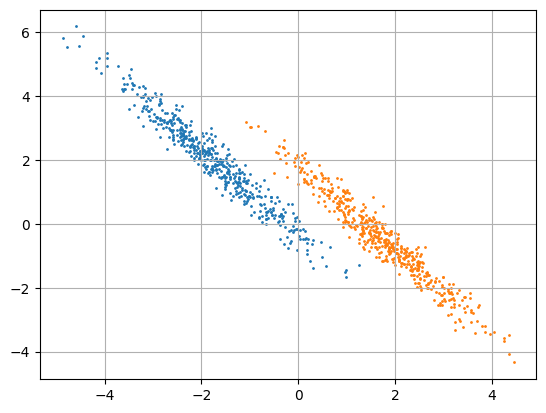

In [85]:
# plot dataset
plt.scatter(x=class_A_data[:, 1], y=class_A_data[:, 2], s=1)
plt.scatter(x=class_B_data[:, 1], y=class_B_data[:, 2], s=1)
plt.grid(True)
plt.show()

In [86]:
'''
Single perceptron algorithm
Assumes that the data can be linearly separated by a hyperplane. Algorithm fails if this is not true
initialise the weight vector to zero.
for each data point (x, y):
  if y*w^T@x <= 0:
    weight vector is wrong
    update weight vector: w_new = w_old + y*x
terminate if there was no weight update (all points successfully classified)
'''
weights = np.zeros((1, 3))
epochs = 0
n_wrong = 0
while True:
  epochs = epochs + 1
  for i in range(data_shuffle.shape[0]):
    result = targets_shuffle[i] * (data_shuffle[i] @ np.transpose(weights))
    if result <= 0.0:
      weights = weights + (targets_shuffle[i] * data_shuffle[i])
      n_wrong = n_wrong + 1
  if n_wrong == 0:
    break
  else:
    n_wrong = 0

In [87]:
# work out the equation of the separating hyperplane

# find the point along the direction of the weight vector that the hyperplane intersects
normalised_bias = weights[0, 0] / np.linalg.norm(weights[0, 1:])
unit_weight_vector = (-weights[0, 1:]) / np.linalg.norm(weights[0, 1:])
# scale unit weight vector by normalised bias
intersection = normalised_bias * unit_weight_vector
# hyperplane is perpendicular to weight vector, so slop of hyperplane is negative reciprocal
slope = weights[0, 2] / weights[0, 1]
hyperplane_slope = -(1 / slope)

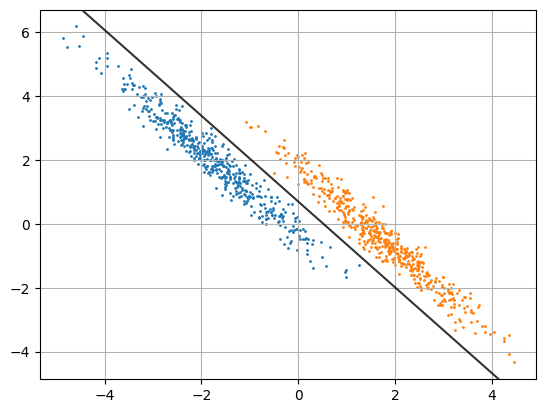

In [88]:
# plot data and separating hyperplane
plt.scatter(x=class_A_data[:, 1], y=class_A_data[:, 2], s=1)
plt.scatter(x=class_B_data[:, 1], y=class_B_data[:, 2], s=1)
plt.axline(xy1=(intersection[0], intersection[1]), slope=hyperplane_slope, c='k', alpha=0.8)
plt.grid(True)
plt.show()